In [34]:
import numpy as np
import xtrack as xt
import xobjects as xo
import xpart as xp
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm
from scipy import constants 
from scipy.optimize import curve_fit
import json

import numpy as np
import matplotlib.pyplot as plt
from scipy import constants 
from scipy.optimize import curve_fit
from ipywidgets import interact, IntSlider
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm
import xtrack as xt
import xpart as xp
import json
import xobjects as xo
from matplotlib.ticker import ScalarFormatter
from tqdm import tqdm
import os
import pickle

textwidth_cm = 15  # Text width in cm
aspect_ratio = 0.618     # Aspect ratio (height/width) using the golden ratio

# Font sizes
label_fontsize = 12
legend_fontsize = 12
tick_fontsize = 10
colorbar_label_fontsize = 12
colorbar_tick_fontsize = 10
offset_text_fontsize = 12
tick_fontsize = 10
errorbar_capsize = 5

# Convert text width from cm to inches
textwidth_in = textwidth_cm / 2.54

# Calculate figure size based on text width and aspect ratio
fig_width = textwidth_in
fig_height = textwidth_in * aspect_ratio

plt.rcParams["figure.figsize"] = [fig_width, fig_height]


plt.rc('font', size=label_fontsize)          # controls default text sizes
plt.rc('axes', titlesize=legend_fontsize)    # fontsize of the axes title
plt.rc('axes', labelsize=tick_fontsize)    # fontsize of the x and y labels
plt.rc('xtick', labelsize=tick_fontsize)   # fontsize of the tick labels
plt.rc('ytick', labelsize=tick_fontsize)   # fontsize of the tick labels
plt.rc('legend', fontsize=legend_fontsize)   # legend fontsize

save_dir = '/home/pkruyt/cernbox/figures_thesis_pdf/cooling_rate_laser_heatmap/'


In [35]:
# import sys
# sys.path.append('/home/pkruyt/cernbox/CERN-coolers/LEIR/ions')

# from ion_properties import ions, IonProperties

In [36]:
# context = xo.ContextCpu(omp_num_threads=4)
context = xo.ContextCpu()

with open('sps.json', 'r') as f:
    line = xt.Line.from_dict(json.load(f))  
particle_ref0=line.particle_ref
line.build_tracker()

clight=constants.speed_of_light
circumference = line.get_length()
twiss=line.twiss()
#%%
###################
# Linear Transfer #
###################

qx=twiss['qx']
qy=twiss['qy']
dqx=twiss['dqx']
dqy=twiss['dqy']
circumference=twiss['s'][-1]
# beta_x=twiss['betx'][-1]
# beta_y=twiss['bety'][-1]

qs=twiss['qs']
bets=twiss['bets0']
voltage_rf=7*1e6
frequency=201.8251348335775*1e6
lag_rf=180
momentum_compaction_factor=twiss['momentum_compaction_factor']
slip_factor=['slip_factor']

# qs=0.0131
# bets=0.063/2e-4

#at interaction points: #from https://anaconda.org/petrenko/li_like_ca_in_sps/notebook
beta_x  =  54.614389 # m
beta_y  =  44.332517 # m
alpha_x = -1.535235
alpha_y =  1.314101

Dx  =  2.444732 # m
Dpx =  0.097522


Dy  =  0.0 # m
Dpy =  0.0

#index of gamma factory along SPS line: 16675

arc = xt.LineSegmentMap(
        qx=qx, qy=qy,
        dqx=0, dqy=0,
        length=circumference,
        alfx=alpha_x,
        alfy=alpha_y,
        betx=beta_x,
        bety=beta_y,
        
        dx=Dx,
        dpx=Dpx,
        dy=Dy,
        dpy=Dpy,
        # qs=qs,
        # bets=bets,
        voltage_rf=voltage_rf,
        lag_rf=lag_rf,
        frequency_rf=frequency,
        momentum_compaction_factor=momentum_compaction_factor,
        longitudinal_mode = 'nonlinear',

        )

Xcoll not installed


Loading line from dict:   0%|          | 0/38786 [00:00<?, ?it/s]

Done loading line from dict.           
Compiling ContextCpu kernels...
Done compiling ContextCpu kernels.


In [37]:
from ion_properties import lead,calcium,xenon,xenon2nd


In [38]:
# injection_nemitt = 1.5*1e-6 # m*rad (normalized emittance)
# injection_dp_p = 2e-4
# sigma_z = 0.063 #https://cds.cern.ch/record/2690736/files/SPSC-I-253.pdf


Loop over both sig_delta and emittance

In [39]:


# sig_delta_list = np.linspace(0.4e-4, 1e-4, 10)
# n_emitt_list=np.linspace(0.5e-6,1.5e-6,10)

n_emitt_list=[0.25*1e-6]
sig_delta_list=[0.25*1e-4]

sig_delta_list=[3.2275491441186016e-05]
n_emitt_list=[4.11678509489011e-07]

sig_delta_list=[3.0e-05]
n_emitt_list=[4.11678509489011e-07]

for ion_loop in [calcium]:
        # Ion properties:
        q0 = ion_loop.q0
        mass0 = ion_loop.mass0

        gamma = ion_loop.gamma_cooling
        beta=  np.sqrt(1-1/(gamma*gamma))
        p0c = mass0*gamma*beta #eV/c

        bunch_intensity = ion_loop.bunch_intensity

        particle_ref = xp.Particles(p0c=p0c, mass0=mass0, q0=q0,gamma0=gamma)

        line.particle_ref=particle_ref


        #nemitt = 1.5e-6 # m*rad (normalized emittance)
        sigma_z = ion_loop.bunch_length #m



        num_particles=int(5e3)

        line_arc=xt.Line(
                elements=[arc])
        line_arc.build_tracker()


        for j, n_emitt_loop in tqdm(enumerate(n_emitt_list)):
            print(f'{j+1}/{len(n_emitt_list)}')    
            for k, sig_delta_loop in enumerate(sig_delta_list):
                sigma_z=sig_delta_loop*np.abs(twiss['bets0'])
                particles = xp.generate_matched_gaussian_bunch(
                        num_particles=num_particles,
                        total_intensity_particles=bunch_intensity,
                        nemitt_x=n_emitt_loop, nemitt_y=1.5*1e-6, sigma_z=sigma_z,
                        particle_ref=particle_ref,
                        line=line_arc,        
                        )
                particles._init_random_number_generator()

                particles0=particles.copy()
                # sigma_dp=2e-4  
                sigma_dp=np.std(particles.delta)
                print(sigma_dp)
                sigma_dp=2e-4  
                
                ##################
                # Laser Cooler #
                ##################

                #laser-ion beam collision angle
                theta_l = 2.6*np.pi/180 # rad
                #theta_l = ion.theta_l
                nx = 0; ny = -np.sin(theta_l); nz = -np.cos(theta_l)

                # Ion excitation energy:
                ion_excited_lifetime=ion_loop.excited_lifetime
                hw0 = ion_loop.hw0 # eV
                hc=constants.hbar*clight/constants.e # eV*m (ħc)
                lambda_0 = 2*np.pi*hc/hw0 # m -- ion excitation wavelength

                lambda_l = ion_loop.lambda_l

                # # Shift laser wavelength for fast longitudinal cooling:5
                # lambda_l = lambda_l*(1+1*sigma_dp) # m

                laser_frequency = clight/lambda_l # Hz
                sigma_w = 2*np.pi*laser_frequency*sigma_dp
                #sigma_w = 2*np.pi*laser_frequency*sigma_dp/2 # for fast longitudinal cooling

                sigma_t = 1/sigma_w # sec -- Fourier-limited laser pulse
                print('Laser pulse duration sigma_t = %.2f ps' % (sigma_t/1e-12))
                print('Laser wavelength = %.2f nm' % (lambda_l/1e-9))

                laser_waist_radius = 1.3e-3 #m
                laser_energy = 5e-3
                #laser_energy = ion.pulse_energy
                laser_x = ion_loop.laser_x
               
                GF_IP = xt.PulsedLaser(
                                laser_x=laser_x,
                                laser_y=0,
                                laser_z=0,
                                
                                laser_direction_nx = 0,
                                laser_direction_ny = ny,
                                laser_direction_nz = nz,
                                laser_energy         = laser_energy, # J
                                laser_duration_sigma = sigma_t, # sec
                                laser_wavelength = lambda_l, # m
                                laser_waist_radius = laser_waist_radius, # m
                                laser_waist_shift = 0, # m
                                ion_excitation_energy = hw0, # eV
                                ion_excited_lifetime  = ion_excited_lifetime, # sec                   
                                )

                # simulation parameters: simulate 10 s of cooling, and take data once every 100 ms
                max_time_s = 0.01
                int_time_s = 0.001
                T_per_turn = circumference/(clight*beta)
                num_turns = int(max_time_s/T_per_turn)
                save_interval = int(int_time_s/T_per_turn)

                # num_turns = int(1e3)
                # save_interval = num_turns/100
                # # save_interval=1

                # create a monitor object, to reduce holded data
                monitor = xt.ParticlesMonitor(start_at_turn=0, stop_at_turn=1,
                                        n_repetitions=int(num_turns/save_interval),
                                        repetition_period=save_interval,
                                        num_particles=num_particles)


                # line.discard_tracker()
                IP_index=16675   
                line.insert_element('monitor', element=monitor, index=IP_index)
                line.insert_element('GF_IP', element=GF_IP, index=IP_index) #this way monitor comes after the laser
                # SPS_line.append_element(monitor,'monitor')
                # SPS_line.append_element(GF_IP,'GF_IP')
                            
                particles=particles0.copy()

                # line = xt.Line(
                #         elements=[monitor,GF_IP,arc])

                context = xo.ContextCpu(omp_num_threads=1)
                line.build_tracker(_context=context)
                # line.optimize_for_tracking()

                line.track(particles, num_turns=num_turns,
                        turn_by_turn_monitor=False,with_progress=False)

                # extract relevant values
                x = monitor.x[:,:,0]
                px = monitor.px[:,:,0]
                y = monitor.y[:,:,0]
                py = monitor.py[:,:,0]
                delta = monitor.delta[:,:,0]
                zeta = monitor.zeta[:,:,0]
                state = monitor.state[:,:,0]
                time = monitor.at_turn[:, 0, 0] * T_per_turn

                gamma_x=(1+alpha_x**2)/beta_x
                gamma_y=(1+alpha_y**2)/beta_y

                action_x = (gamma_x*(x-Dx*delta)**2 + 2*alpha_x*(x-Dx*delta)*(px-Dpx*delta)+ beta_x*(px-Dpx*delta)**2)
                action_y = (gamma_y*(y-Dy*delta)**2 + 2*alpha_y*(y-Dy*delta)*(py-Dpy*delta)+ beta_y*(py-Dpy*delta)**2)

                emittance_x=np.mean(action_x,axis=1)*gamma/2

                # Define the exponential function
                def exponential_func(x, a, b):
                        return a * np.exp(x * b)
                
                # Fit the data to the exponential function
                params_transverse, covariance = curve_fit(exponential_func, time, emittance_x)

                # Extract the parameters
                a, b = params_transverse

                transverse_cooling_rate=b

                # plt.plot(time,emittance_x*1e6, linewidth=5.0)
                # plt.plot(time, exponential_func(time,
                # *params_transverse) * 1e6, linestyle='--')
                
                # Fit the data to the exponential function
                                
                #################################################################

                # Calculate mean and standard deviation along the particle axis (axis=1)
                mean_z = np.mean(zeta, axis=1)
                mean_delta = np.mean(delta, axis=1)
                sigma_z = np.std(zeta, axis=1)
                sigma_delta = np.std(delta, axis=1)

                # Calculate the covariance between zeta and delta for each turn
                cov_z_delta = np.mean(zeta * delta, axis=1) - mean_z * mean_delta

                # Calculate longitudinal emittance for each turn
                longitudinal_emittance = np.sqrt(sigma_z**2 * sigma_delta**2 - cov_z_delta**2)

                params_longitudinal_emittance, covariance = curve_fit(exponential_func, time, longitudinal_emittance)
                a, b = params_longitudinal_emittance

                longitudinal_emittance_growth_rate=b
                excited=state==2
                fraction_excitation = sum(excited)/len(excited)*100    
                #################################################################################
    
                #transverse_cooling_rate_array[k, j] = transverse_cooling_rate
                #ongitudinal_emittance_growth_rate_array[k, j]=longitudinal_emittance_growth_rate

        # np.savez(f'results/weird_heating/{ion_loop.name}.npz',
        #         transverse_cooling_rate_array=transverse_cooling_rate_array,
        #         #     longitudinal_growth_rate_array=longitudinal_growth_rate_array,
        #         longitudinal_emittance_growth_rate_array=longitudinal_emittance_growth_rate_array,
        #         sig_delta_list=sig_delta_list,
        #         n_emitt_list=n_emitt_list
        #         )

Compiling ContextCpu kernels...
Done compiling ContextCpu kernels.


0it [00:00, ?it/s]

1/1
2.1068224093478856e-05
Laser pulse duration sigma_t = 2.04 ps
Laser wavelength = 768.00 nm
Compiling ContextCpu kernels...
Done compiling ContextCpu kernels.


1it [05:09, 309.15s/it]


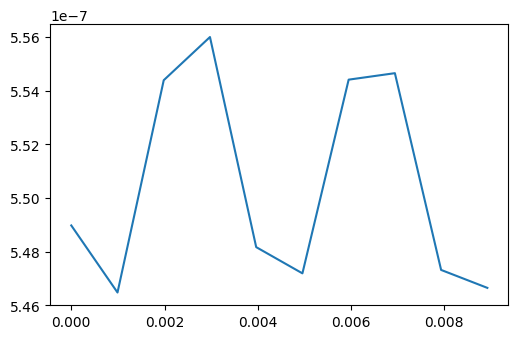

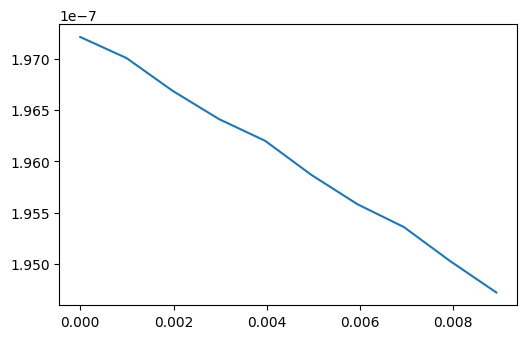

In [40]:
plt.figure()
plt.plot(time,emittance_x)
plt.show()

plt.figure()
plt.plot(time,longitudinal_emittance)
plt.show()

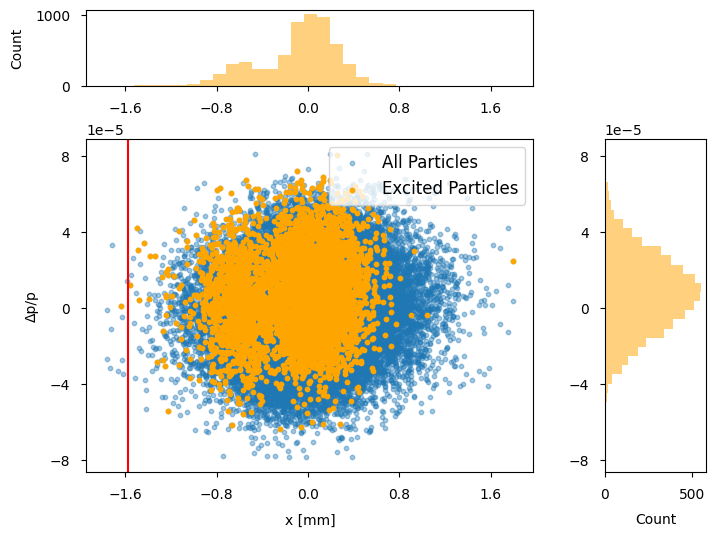

[ 0. 10.  0. ... 10. 20.  0.]


In [41]:
import os
import pickle
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import numpy as np
from matplotlib.ticker import MaxNLocator


# Create figure with slightly relaxed spacing
fig = plt.figure(figsize=(8, 6))
gs = gridspec.GridSpec(4, 4, wspace=0.7, hspace=0.7)

# Define subplots
ax_main = fig.add_subplot(gs[1:4, 0:3])
ax_top = fig.add_subplot(gs[0, 0:3], sharex=ax_main)
ax_right = fig.add_subplot(gs[1:4, 3], sharey=ax_main)

# -----------------------------------------------------
# 1. Main scatter plot: show all particles and excited particles
# -----------------------------------------------------
# Multiply x by 1000 to convert to mm
ax_main.scatter(x * 1e3, delta, s=10, alpha=0.4, label='All Particles')
ax_main.scatter(x[excited] * 1e3, delta[excited], s=10, color='orange', label='Excited Particles')
ax_main.set_xlabel('x [mm]', labelpad=8)
ax_main.set_ylabel('Δp/p', labelpad=8)
ax_main.legend(loc='upper right')

# -----------------------------------------------------
# 2. Format axes: Using MaxNLocator and scientific notation
# -----------------------------------------------------
ax_main.xaxis.set_major_locator(MaxNLocator(5))
ax_main.yaxis.set_major_locator(MaxNLocator(5))
ax_top.xaxis.set_major_locator(MaxNLocator(5))
ax_right.yaxis.set_major_locator(MaxNLocator(5))

ax_main.ticklabel_format(style='sci', axis='both', scilimits=(0, 0))
ax_main.tick_params(axis='both', which='major', pad=8)
ax_top.tick_params(axis='both', which='major', pad=8)
ax_right.tick_params(axis='both', which='major', pad=8)

# -----------------------------------------------------
# 3. Top histogram: x distribution for excited particles only
# -----------------------------------------------------
bins_x = 30
ax_top.hist(x[excited] * 1e3, bins=bins_x, alpha=0.5, color='orange')
ax_top.set_ylabel('Count', labelpad=8)

# -----------------------------------------------------
# 4. Right histogram: Δp/p distribution for excited particles only
# -----------------------------------------------------
bins_delta = 30
ax_right.hist(delta[excited], bins=bins_delta, orientation='horizontal',
              alpha=0.5, color='orange')
ax_right.set_xlabel('Count', labelpad=8)

ax_main.axvline(ion_loop.laser_x*1e3,color='red',label='Laser location')

# -----------------------------------------------------
# Save image and pickle the figure
# -----------------------------------------------------
image_name = 'calcium_heating.pdf'
save_location = os.path.join(save_dir, image_name)
plt.savefig(save_location, dpi=300, bbox_inches='tight')

pickle_filename = 'calcium_heating.pkl'
pickle_file_path = os.path.join(save_dir, pickle_filename)
with open(pickle_file_path, 'wb') as f:
    pickle.dump(fig, f)

plt.show()
print(fraction_excitation)

In [43]:
1.643/0.029226287254179285

56.21651445874485

In [42]:
# --- before your plotting, extract turn 0 ---
x0       = x[0, :]            # positions at first turn
delta0   = delta[0, :]        # dp/p at first turn
excited0 = excited[0, :]      # boolean mask at first turn

# (if fraction_excitation is also per‑turn, grab its first element)
frac0 = fraction_excitation[0]

# -----------------------------------------------------
# 1. Main scatter plot: show only turn 0
# -----------------------------------------------------
ax_main.scatter(x0 * 1e3, delta0,        s=10, alpha=0.4, label='All Particles')
ax_main.scatter(x0[excited0] * 1e3, delta0[excited0],
                s=10, color='orange',   label='Excited Particles')

# -----------------------------------------------------
# 3. Top histogram: x distribution for excited particles only (turn 0)
# -----------------------------------------------------
ax_top.hist(x0[excited0] * 1e3, bins=bins_x, alpha=0.5, color='orange')

# -----------------------------------------------------
# 4. Right histogram: Δp/p distribution for excited particles only (turn 0)
# -----------------------------------------------------
ax_right.hist(delta0[excited0], bins=bins_delta,
              orientation='horizontal', alpha=0.5, color='orange')

# -----------------------------------------------------
# After plt.show(), print only the first-turn fraction
# -----------------------------------------------------
plt.show()
print("Fraction excited (turn 0):", frac0)


Fraction excited (turn 0): 0.0
